# Graph Neural Networks — Mathematical Foundations & Implementation

**A from-scratch, runnable reference.** This notebook builds the core Graph Neural Network (GNN)
architectures *from the math up*, in pure **PyTorch + NumPy + NetworkX** — no PyTorch Geometric or
DGL required. The goal is to make every equation correspond to a few lines of transparent code, so
you can see exactly what a "graph convolution" or an "attention head" actually computes.

### What's covered

| Part | Topic | Math | Code |
|---|---|---|---|
| 0 | Environment & setup | — | versions, seeds, device |
| 1 | Graphs as data | $G=(V,E)$, $A$, $D$, $X$; permutation symmetry | dense / COO `edge_index` / features |
| 2 | The graph Laplacian | $L=D-A$, $L_{sym}$, spectrum, graph Fourier transform | eigendecomposition, signal smoothness |
| 3 | Spectral → spatial | spectral convolution → ChebNet → **GCN** renormalization | $\hat{A}=\tilde D^{-1/2}\tilde A\tilde D^{-1/2}$ |
| 4 | Message Passing (MPNN) | message / aggregate / update | dense **vs** scatter — proven identical |
| 5 | GCN from scratch | $H^{(l+1)}=\sigma(\hat A H^{(l)} W^{(l)})$ | `nn.Module` layers |
| 6 | Node classification | semi-supervised loss, masks | Zachary's Karate Club, embedding evolution |
| 7 | **GraphSAGE** | inductive sample-and-aggregate | mean aggregator via scatter |
| 8 | **GAT** | attention coefficients, multi-head | segment-softmax, attention viz |
| 9 | Graph-level tasks | permutation-invariant readout, batching | block-diagonal batching, graph classification |
| 10 | Limitations & theory | over-smoothing, over-squashing, 1-WL expressiveness | empirical demonstrations |
| 11 | Cheat sheet & references | layer-rule summary table | canonical papers |

### How to run
- **Kernel:** select **Python (MLENV311)**.
- **Run order:** top-to-bottom (`Run All`). Every cell is deterministic (fixed seeds), so numbers and
  figures reproduce exactly.
- **Dependencies:** `torch, numpy, scipy, networkx, matplotlib, scikit-learn` — all present in `MLENV311`.
- **Datasets:** none downloaded. We use Zachary's Karate Club (ships with NetworkX) and small synthetic
  graphs, so the notebook is fully offline and fast.

> **Why from scratch?** Calling `GCNConv(...)` teaches you an API. Writing $\hat A H W$ and then proving
> it equals a `scatter_add` over edges teaches you the *model*. Once these ~40 lines make sense, the
> library versions are trivial to read.

## Part 0 — Environment & setup

We pin a single random seed and run on CPU. These graphs are tiny (tens to hundreds of nodes), so CPU is
instant *and* fully deterministic; Apple-Silicon `mps` is available if you want to exercise it, but it can
differ in the last few digits, so we keep CPU for exact reproducibility.

In [1]:
import sys, platform
import numpy as np
import scipy
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

print("Python      :", sys.version.split()[0], "|", platform.platform())
print("numpy       :", np.__version__)
print("scipy       :", scipy.__version__)
print("networkx    :", nx.__version__)
print("matplotlib  :", matplotlib.__version__)
print("torch       :", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())

Python      : 3.11.15 | macOS-26.5.1-arm64-arm-64bit
numpy       : 2.0.2
scipy       : 1.17.1
networkx    : 3.6.1
matplotlib  : 3.10.0
torch       : 2.12.0
MPS available: True


In [2]:
def set_seed(seed: int = 0):
    """One knob for full reproducibility across NumPy and PyTorch."""
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(0)

# CPU is deterministic and more than fast enough for these graphs.
# To try Apple-Silicon acceleration, set DEVICE = torch.device("mps").
DEVICE = torch.device("cpu")
print("Using device:", DEVICE)

Using device: cpu


## Part 1 — Graphs as data

A graph is $G=(V,E)$ with $N=|V|$ nodes. We summarize it with a few matrices:

- **Adjacency** $A \in \mathbb{R}^{N\times N}$: $A_{ij}=1$ if edge $(i,j)\in E$, else $0$. For an
  *undirected* graph $A=A^\top$.
- **Degree** $D=\mathrm{diag}(d_1,\dots,d_N)$ with $d_i=\sum_j A_{ij}$ (number of neighbors).
- **Node features** $X \in \mathbb{R}^{N\times F}$: row $i$ is the $F$-dim feature vector of node $i$.
- (Optionally) **edge features** $e_{ij}$ and a **label** per node / per edge / per whole graph.

GNNs solve three task families:

| Task | Predict | Example |
|---|---|---|
| **Node-level** | a label per node | classify users in a social network |
| **Edge-level** | a label per (possible) edge | link prediction / recommendation |
| **Graph-level** | one label per whole graph | is this molecule toxic? |

### The defining constraint: permutation symmetry
Nodes have **no canonical order**. Relabeling them with a permutation matrix $P$ sends
$A \mapsto PAP^\top$ and $X \mapsto PX$ — a *different* set of matrices describing the *same* graph.
A correct node-wise layer $f$ must therefore be **permutation-equivariant**, $f(PAP^\top, PX)=P\,f(A,X)$,
and a graph-level readout must be **permutation-invariant**. This single requirement is *why* we cannot
just flatten $A$ and feed it to an MLP, and *why* every GNN layer is built from symmetric neighborhood
aggregation.

In [3]:
# A tiny undirected graph (6 nodes) so every matrix is readable by eye.
edges = [(0,1),(0,2),(1,2),(2,3),(3,4),(3,5),(4,5)]
G_toy = nx.Graph()
G_toy.add_nodes_from(range(6))
G_toy.add_edges_from(edges)

A = nx.to_numpy_array(G_toy, nodelist=range(6))   # dense adjacency, shape [N, N]
deg = A.sum(axis=1)                                # degree = row sum
print("Adjacency A (NxN):")
print(A.astype(int))
print("\nDegrees d_i:", deg.astype(int))
print("Symmetric (undirected)? ", bool(np.allclose(A, A.T)))

Adjacency A (NxN):
[[0 1 1 0 0 0]
 [1 0 1 0 0 0]
 [1 1 0 1 0 0]
 [0 0 1 0 1 1]
 [0 0 0 1 0 1]
 [0 0 0 1 1 0]]

Degrees d_i: [2 2 3 3 2 2]
Symmetric (undirected)?  True


In [4]:
# COO / "edge_index" representation: the sparse format PyTorch Geometric & DGL use internally.
# Each undirected edge {i, j} becomes TWO directed entries  i->j  and  j->i.
src, dst = np.nonzero(A)
edge_index = np.vstack([src, dst])                 # shape [2, num_directed_edges]
print("edge_index (2 x E):")
print(edge_index)
print("num directed edges E =", edge_index.shape[1], " (= 2 x", G_toy.number_of_edges(), "undirected)")
# Memory note: dense A is O(N^2); edge_index is O(E). Real graphs are sparse (E << N^2),
# so edge_index is what scales. We use dense A below only because N is tiny and it is readable.

edge_index (2 x E):
[[0 0 1 1 2 2 2 3 3 3 4 4 5 5]
 [1 2 0 2 0 1 3 2 4 5 3 5 3 4]]
num directed edges E = 14  (= 2 x 7 undirected)


In [5]:
# Node feature matrix X in R^{N x F}. Here we hand a 2-D toy feature to each node.
rng = np.random.default_rng(0)
X_toy = rng.normal(size=(6, 2)).round(2)
print("Feature matrix X (N x F), F=2:")
print(X_toy)

Feature matrix X (N x F), F=2:
[[ 0.13 -0.13]
 [ 0.64  0.1 ]
 [-0.54  0.36]
 [ 1.3   0.95]
 [-0.7  -1.27]
 [-0.62  0.04]]


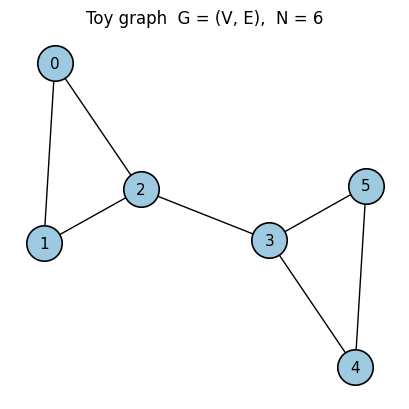

In [6]:
# Visualize the toy graph with a fixed layout.
fig, ax = plt.subplots(figsize=(4.2, 4.2))
pos = nx.spring_layout(G_toy, seed=1)
nx.draw_networkx(G_toy, pos, node_color="#9ecae1", node_size=650,
                 edgecolors="black", linewidths=1.2, font_size=11, ax=ax)
ax.set_title("Toy graph  G = (V, E),  N = 6")
ax.axis("off")
plt.tight_layout(); plt.show()

In [7]:
# Permutation symmetry, made concrete: relabeling nodes gives P A P^T -- a DIFFERENT matrix,
# the SAME graph. This is exactly why GNN layers must be permutation-equivariant.
perm = np.random.default_rng(1).permutation(6)
P = np.eye(6)[perm]                # permutation matrix
A_perm = P @ A @ P.T
print("permutation:", perm)
print("Is P A P^T a different matrix than A? ", not np.array_equal(A, A_perm))
print("Same graph (identical sorted degree sequence)? ",
      sorted(A.sum(1).astype(int)) == sorted(A_perm.sum(1).astype(int)))
print("\nAn MLP on flattened A would give different outputs for these two -- a bug.")
print("A GNN aggregates over neighbors, so it gives the SAME answer (up to relabeling).")

permutation: [4 0 2 1 5 3]
Is P A P^T a different matrix than A?  True
Same graph (identical sorted degree sequence)?  True

An MLP on flattened A would give different outputs for these two -- a bug.
A GNN aggregates over neighbors, so it gives the SAME answer (up to relabeling).


## Part 2 — The graph Laplacian and the spectral viewpoint

The **(combinatorial) graph Laplacian** is

$$ L = D - A. $$

It is the discrete analogue of the continuous Laplacian $-\nabla^2$, and it is the bridge to *spectral*
GNNs. Its **symmetric normalized** form is

$$ L_{sym} = I - D^{-1/2} A D^{-1/2}, $$

which is symmetric positive semidefinite, so it has an orthonormal eigenbasis
$L_{sym}=U\Lambda U^\top$ with real eigenvalues $0=\lambda_1\le\lambda_2\le\dots\le\lambda_N\le 2$.

**Why the Laplacian measures smoothness.** For any signal $x\in\mathbb{R}^N$ on the nodes,

$$ x^\top L x \;=\; \tfrac12\sum_{(i,j)} A_{ij}\,(x_i-x_j)^2 \;\ge\; 0, $$

the **Dirichlet energy** — small when neighbors share similar values (a *smooth* signal), large when they
disagree. The eigenvectors $u_k$ are the graph's "Fourier modes": low eigenvalues $\Rightarrow$ smooth
modes, high eigenvalues $\Rightarrow$ oscillatory modes. The **graph Fourier transform** is
$\hat{x}=U^\top x$, and *filtering in the spectral domain* is the original definition of a graph
convolution (Part 3).

In [8]:
def laplacians(A):
    """Return (L, L_sym) for a dense adjacency A."""
    A = np.asarray(A, dtype=float)
    d = A.sum(1)
    L = np.diag(d) - A                              # combinatorial Laplacian  L = D - A
    d_inv_sqrt = np.zeros_like(d)
    nz = d > 0
    d_inv_sqrt[nz] = d[nz] ** -0.5
    Disq = np.diag(d_inv_sqrt)
    L_sym = np.eye(len(A)) - Disq @ A @ Disq         # I - D^{-1/2} A D^{-1/2}
    return L, L_sym

def dirichlet_energy(H, L):
    """Dirichlet energy trace(H^T L H): total disagreement of H across edges (per feature, summed)."""
    H = np.asarray(H, dtype=float)
    return float(np.trace(H.T @ L @ H))

# Use Zachary's Karate Club (34 nodes) for the rest of the spectral discussion.
G = nx.karate_club_graph()
nodelist = sorted(G.nodes)
A_k = (nx.to_numpy_array(G, nodelist=nodelist) > 0).astype(float)  # binarize: karate ships w/ edge weights
L, L_sym = laplacians(A_k)

# Verify the smoothness identity  x^T L x = 1/2 sum_ij A_ij (x_i - x_j)^2  on a random signal.
x = np.random.default_rng(0).normal(size=A_k.shape[0])
quad = float(x @ L @ x)
pair = 0.5 * float(sum(A_k[i, j] * (x[i] - x[j])**2
                       for i in range(len(x)) for j in range(len(x))))
print(f"x^T L x                       = {quad:.6f}")
print(f"1/2 * sum A_ij (x_i - x_j)^2  = {pair:.6f}")
print("identity holds:", np.isclose(quad, pair))

x^T L x                       = 78.638227
1/2 * sum A_ij (x_i - x_j)^2  = 78.638227
identity holds: True


smallest 4 eigenvalues: [0.     0.1323 0.287  0.3873]
largest eigenvalue    : 1.7146  (theory: <= 2 for L_sym)

Dirichlet energy of Fiedler vector  u_2 : 0.1323  (smooth)
Dirichlet energy of top mode       u_N : 1.7146  (oscillatory)


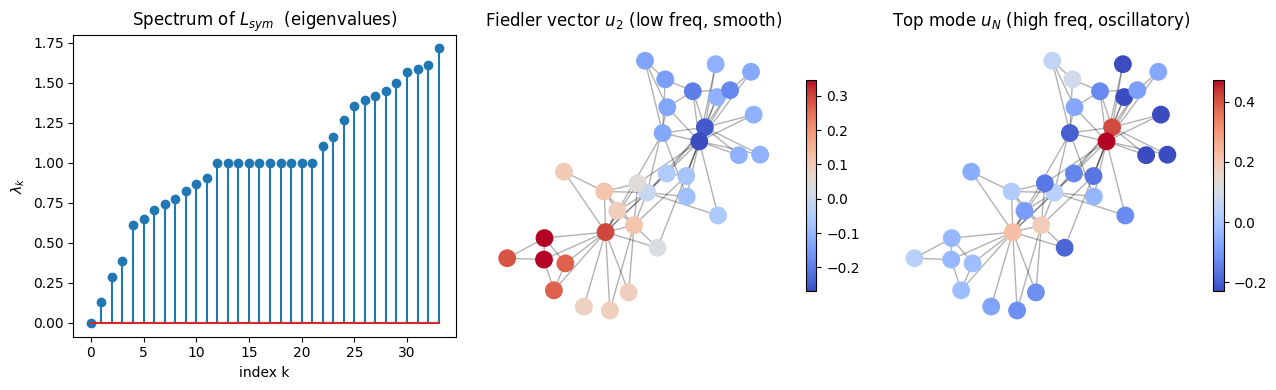

In [9]:
# Eigendecomposition of the symmetric normalized Laplacian (eigh -> ascending eigenvalues).
evals, evecs = np.linalg.eigh(L_sym)
print("smallest 4 eigenvalues:", np.round(evals[:4], 4))
print("largest eigenvalue    :", round(evals[-1], 4), " (theory: <= 2 for L_sym)")

# The first nonzero eigenvector (Fiedler vector) is SMOOTH -> reveals community structure.
# A high-index eigenvector OSCILLATES -> neighbors disagree.
fiedler = evecs[:, 1]
high_freq = evecs[:, -1]
print(f"\nDirichlet energy of Fiedler vector  u_2 : {float(fiedler @ L_sym @ fiedler):.4f}  (smooth)")
print(f"Dirichlet energy of top mode       u_N : {float(high_freq @ L_sym @ high_freq):.4f}  (oscillatory)")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pos = nx.spring_layout(G, seed=2)

axes[0].stem(range(len(evals)), evals)
axes[0].set_title("Spectrum of $L_{sym}$  (eigenvalues)")
axes[0].set_xlabel("index k"); axes[0].set_ylabel(r"$\lambda_k$")

for ax, vec, name in [(axes[1], fiedler, "Fiedler vector $u_2$ (low freq, smooth)"),
                      (axes[2], high_freq, "Top mode $u_N$ (high freq, oscillatory)")]:
    nc = nx.draw_networkx_nodes(G, pos, node_color=vec, cmap="coolwarm",
                                node_size=140, ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)
    ax.set_title(name); ax.axis("off")
    fig.colorbar(nc, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()

## Part 3 — From spectral convolution to the GCN

**1. Spectral convolution.** Convolution = pointwise multiplication in the Fourier domain. On a graph,
a filter $g_\theta$ acts on a signal $x$ as

$$ g_\theta \star x = U\, g_\theta(\Lambda)\, U^\top x . $$

This is *exact* but costs a full eigendecomposition ($O(N^3)$) and the filter is not localized.

**2. ChebNet (Defferrard et al., 2016).** Approximate $g_\theta(\Lambda)$ by a degree-$K$ Chebyshev
polynomial in $\tilde\Lambda$. Polynomials of $L$ are **$K$-localized** (only reach $K$-hop neighbors)
and need **no eigendecomposition** — just sparse matrix-vector products:

$$ g_\theta \star x \approx \sum_{k=0}^{K} \theta_k\, T_k(\tilde L)\, x . $$

**3. GCN (Kipf & Welling, 2017).** Take $K=1$, fix $\lambda_{max}\approx 2$, share one parameter, and
add the **renormalization trick** $A \to \tilde A = A + I$ (self-loops) with $\tilde D_{ii}=\sum_j\tilde A_{ij}$.
The single graph-convolution layer collapses to the famous propagation rule:

$$ \boxed{\,H^{(l+1)} = \sigma\!\big(\hat A\, H^{(l)}\, W^{(l)}\big)\,}, \qquad
   \hat A = \tilde D^{-1/2}\,\tilde A\,\tilde D^{-1/2}. $$

The renormalization keeps the spectrum of $\hat A$ in a stable range (largest eigenvalue $\approx 1$),
which prevents the repeated multiplication in deep stacks from exploding or vanishing — we verify this
numerically below.

In [10]:
def gcn_norm(A):
    """Renormalized adjacency  A_hat = D~^{-1/2} (A + I) D~^{-1/2}  with self-loops added."""
    A = np.asarray(A, dtype=float)
    A_tilde = A + np.eye(len(A))                    # add self-loops
    d = A_tilde.sum(1)                              # degrees of A_tilde
    Disq = np.diag(d ** -0.5)
    return Disq @ A_tilde @ Disq

A_hat = gcn_norm(A_k)
ev = np.linalg.eigvalsh(A_hat)
print(f"eigenvalues of A_hat lie in [{ev.min():.3f}, {ev.max():.3f}]")
print("largest eigenvalue ~ 1.0:", np.isclose(ev.max(), 1.0, atol=1e-6))
print("\nCompare: spectral radius of the *un-normalized* A is",
      f"{np.abs(np.linalg.eigvalsh(A_k)).max():.2f}  ->  repeated multiplication would explode.")
print("Renormalization is what makes stacking many layers numerically sane.")

eigenvalues of A_hat lie in [-0.420, 1.000]
largest eigenvalue ~ 1.0: True

Compare: spectral radius of the *un-normalized* A is 6.73  ->  repeated multiplication would explode.
Renormalization is what makes stacking many layers numerically sane.


## Part 4 — The Message Passing framework (MPNN)

Almost every modern GNN is an instance of the **Message Passing Neural Network** (Gilmer et al., 2017).
For each node $i$, one layer does three things:

$$
\underbrace{m_{i\leftarrow j} = \mathrm{MESSAGE}\big(h_i, h_j, e_{ij}\big)}_{\text{1. message along each edge}}
\quad\rightarrow\quad
\underbrace{a_i = \bigoplus_{j\in\mathcal N(i)} m_{i\leftarrow j}}_{\text{2. permutation-invariant aggregate}}
\quad\rightarrow\quad
\underbrace{h_i' = \mathrm{UPDATE}\big(h_i, a_i\big)}_{\text{3. update}}
$$

The aggregator $\bigoplus$ (sum / mean / max) **must be permutation-invariant** — that is what makes the
whole layer permutation-equivariant. **GCN is the special case**

$$ m_{i\leftarrow j} = \tfrac{1}{\sqrt{\tilde d_i}\sqrt{\tilde d_j}}\,(h_j W),\qquad
   \oplus=\text{sum},\qquad \mathrm{UPDATE}=\sigma. $$

There are two equivalent ways to implement it, and seeing they match is the single most clarifying moment
in GNNs:

- **Dense / matrix form** — $\hat A H W$. Elegant, but materializes the $N\times N$ matrix.
- **Scatter / edge form** — gather source features, scale per edge, `scatter_add` into destinations.
  This is $O(E)$ and is exactly what PyG/DGL do under the hood.

The next cell implements the scatter form by hand and proves it equals the dense form.

In [11]:
def add_self_loops(edge_index, num_nodes):
    """Append i->i for every node (GCN aggregates over N(i) UNION {i})."""
    loops = np.vstack([np.arange(num_nodes), np.arange(num_nodes)])
    return np.concatenate([edge_index, loops], axis=1)

def gcn_message_passing(X, edge_index, num_nodes):
    """One GCN propagation step in pure SCATTER form -- no dense N x N matrix is ever built.

    For each directed edge src -> dst:
        message = (1/sqrt(deg_dst)) * (1/sqrt(deg_src)) * X[src]
    then sum all messages arriving at each dst.  Degrees include the self-loop (i.e. degrees of A~).
    """
    ei = add_self_loops(edge_index, num_nodes)
    src, dst = ei[0], ei[1]
    deg = np.bincount(dst, minlength=num_nodes)          # in-degree incl. self-loop = deg(A~)
    norm = deg[src] ** -0.5 * deg[dst] ** -0.5           # symmetric normalization per edge
    out = np.zeros_like(X, dtype=float)
    np.add.at(out, dst, norm[:, None] * X[src])          # scatter-add messages into destinations
    return out

# Prove the two implementations are identical on a random feature matrix.
set_seed(0)
Xr = np.random.default_rng(0).normal(size=(A_k.shape[0], 5))
src, dst = np.nonzero(A_k)
ei = np.vstack([src, dst])

out_dense = A_hat @ Xr                                   # dense form:  A_hat @ X
out_scatter = gcn_message_passing(Xr, ei, A_k.shape[0])  # scatter form over edges

print("dense form  ==  message-passing form :", np.allclose(out_dense, out_scatter))
print("max abs difference                   :", float(np.abs(out_dense - out_scatter).max()))
print("\nSame computation, two views: matrix algebra vs. explicit per-edge messages.")

dense form  ==  message-passing form : True
max abs difference                   : 2.220446049250313e-16

Same computation, two views: matrix algebra vs. explicit per-edge messages.


## Part 5 — A GCN layer and network from scratch (PyTorch)

Now in PyTorch, using the dense form for clarity (the graph is small, $\hat A$ is precomputed once).
A `GCNLayer` is just a linear map followed by neighborhood mixing: $\hat A\,(HW)$. We use **Glorot/Xavier**
initialization, exactly as in the original paper, and a standard 2-layer network with ReLU + dropout.

In [12]:
class GCNLayer(nn.Module):
    """Graph-convolution layer:  H' = A_hat @ (H W) + b.

    A_hat is the fixed renormalized adjacency for the graph; the linear map carries the
    learnable weights W. (nn.Linear computes H W^T + b; the transpose is absorbed into W.)
    """
    def __init__(self, in_dim, out_dim, bias=True):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=bias)
        nn.init.xavier_uniform_(self.lin.weight)         # Glorot init (Kipf & Welling)
        if bias:
            nn.init.zeros_(self.lin.bias)

    def forward(self, H, A_hat):
        return A_hat @ self.lin(H)                        # neighbor mixing after the linear map


class GCN(nn.Module):
    """Two-layer GCN for node classification (logits out; softmax handled by the loss)."""
    def __init__(self, in_dim, hid_dim, out_dim, dropout=0.5):
        super().__init__()
        self.gc1 = GCNLayer(in_dim, hid_dim)
        self.gc2 = GCNLayer(hid_dim, out_dim)
        self.dropout = dropout

    def forward(self, X, A_hat):
        h = F.relu(self.gc1(X, A_hat))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.gc2(h, A_hat)                         # raw logits

# Sanity check on shapes.
_m = GCN(in_dim=5, hid_dim=4, out_dim=2)
_A = torch.tensor(A_hat, dtype=torch.float32)
_X = torch.tensor(Xr, dtype=torch.float32)
print("GCN output shape (N x num_classes):", tuple(_m(_X, _A).shape))
print("trainable parameters:", sum(p.numel() for p in _m.parameters()))

GCN output shape (N x num_classes): (34, 2)
trainable parameters: 34


## Part 6 — Semi-supervised node classification (Zachary's Karate Club)

The canonical GCN demo. Zachary's Karate Club is a real social network of 34 members that famously split
into two factions (the instructor **"Mr. Hi"** and the officer **"Officer"**). We reveal the label of
**only two nodes** — node 0 (Mr. Hi) and node 33 (the Officer) — and ask the GCN to label everyone else.

**Featureless input.** We set $X=I_N$ (a one-hot identity), so the model has *no* node features to lean
on — it must learn purely from graph structure as $\hat A$ propagates the two known labels across the
edges.

**Semi-supervised loss.** We compute cross-entropy on the labeled nodes only, via a boolean `train_mask`:

$$ \mathcal L = -\frac{1}{|\mathcal L|}\sum_{i\in\mathcal L}\log \mathrm{softmax}(z_i)_{y_i}. $$

We make the final layer 2-dimensional so its output doubles as a **2-D embedding we can plot directly**,
and watch the two communities separate as training proceeds.

In [13]:
G = nx.karate_club_graph()
N = G.number_of_nodes()
nodelist = sorted(G.nodes)
A_k = (nx.to_numpy_array(G, nodelist=nodelist) > 0).astype(float)  # binarize: karate ships w/ edge weights

A_hat_t = torch.tensor(gcn_norm(A_k), dtype=torch.float32, device=DEVICE)
X_id    = torch.eye(N, device=DEVICE)                    # featureless one-hot identity

# Ground-truth community of every node (for evaluation only).
y_true = torch.tensor([0 if G.nodes[i]["club"] == "Mr. Hi" else 1 for i in nodelist],
                      dtype=torch.long, device=DEVICE)

# Semi-supervised: only the two "leaders" are labeled during training.
train_mask = torch.zeros(N, dtype=torch.bool, device=DEVICE)
train_mask[0]  = True     # Mr. Hi
train_mask[33] = True     # Officer
print("labeled nodes:", train_mask.nonzero().flatten().tolist(),
      "  (the rest are inferred from structure)")
print("class balance (ground truth):", torch.bincount(y_true).tolist())

labeled nodes: [0, 33]   (the rest are inferred from structure)
class balance (ground truth): [17, 17]


In [14]:
set_seed(1)
model = GCN(in_dim=N, hid_dim=16, out_dim=2, dropout=0.1).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=0.02, weight_decay=5e-4)

history = {"epoch": [], "loss": [], "acc": []}
snapshots = {}                                           # epoch -> 2-D embeddings
SNAP_AT = {0, 30, 80, 300}

for epoch in range(0, 301):
    model.train(); opt.zero_grad()
    logits = model(X_id, A_hat_t)
    loss = F.cross_entropy(logits[train_mask], y_true[train_mask])
    loss.backward(); opt.step()

    model.eval()
    with torch.no_grad():
        z = model(X_id, A_hat_t)
        acc = (z.argmax(1) == y_true).float().mean().item()
    history["epoch"].append(epoch); history["loss"].append(loss.item()); history["acc"].append(acc)
    if epoch in SNAP_AT:
        snapshots[epoch] = z.detach().cpu().numpy()
    if epoch % 50 == 0:
        print(f"epoch {epoch:3d} | loss {loss.item():.4f} | full-graph acc {acc:.3f}")

print(f"\nFinal accuracy on all {N} nodes (trained from just 2 labels): {history['acc'][-1]:.3f}")

epoch   0 | loss 0.6392 | full-graph acc 0.853
epoch  50 | loss 0.0004 | full-graph acc 0.971
epoch 100 | loss 0.0016 | full-graph acc 0.971
epoch 150 | loss 0.0027 | full-graph acc 0.971
epoch 200 | loss 0.0015 | full-graph acc 0.971
epoch 250 | loss 0.0013 | full-graph acc 0.971
epoch 300 | loss 0.0026 | full-graph acc 0.971

Final accuracy on all 34 nodes (trained from just 2 labels): 0.971


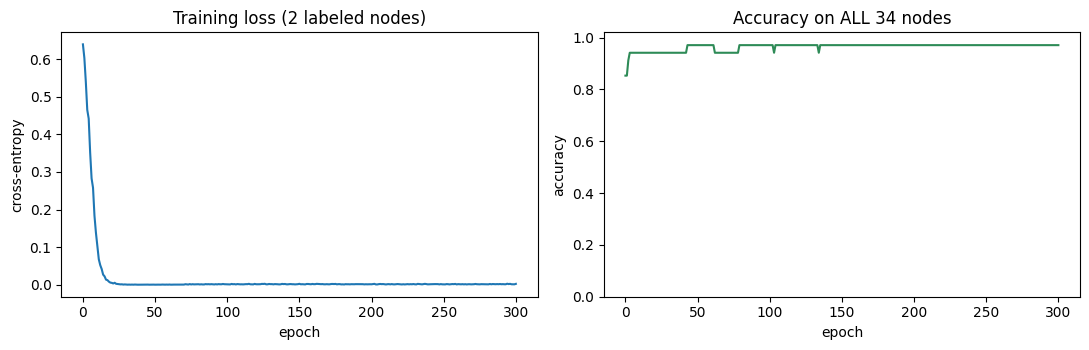

In [15]:
# Training curves.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(history["epoch"], history["loss"]); ax[0].set_title("Training loss (2 labeled nodes)")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("cross-entropy")
ax[1].plot(history["epoch"], history["acc"], color="seagreen")
ax[1].set_title("Accuracy on ALL 34 nodes"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
ax[1].set_ylim(0, 1.02)
plt.tight_layout(); plt.show()

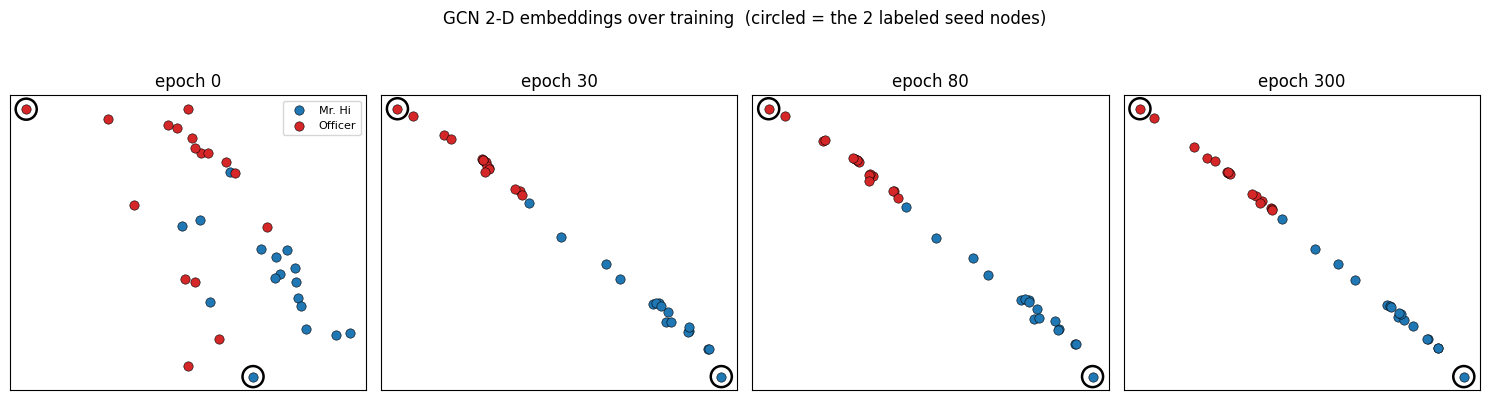

In [16]:
# Embedding evolution: the 2-D output space, colored by TRUE community, at four training stages.
# Watch the two factions pull apart as label information propagates through A_hat.
y_np = y_true.cpu().numpy()
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, ep in zip(axes, sorted(snapshots)):
    z = snapshots[ep]
    for c, color, name in [(0, "#1f77b4", "Mr. Hi"), (1, "#d62728", "Officer")]:
        m = y_np == c
        ax.scatter(z[m, 0], z[m, 1], c=color, s=45, edgecolors="k", linewidths=0.4, label=name)
    # mark the two supervised seed nodes
    for s in (0, 33):
        ax.scatter(z[s, 0], z[s, 1], s=230, facecolors="none", edgecolors="black", linewidths=1.8)
    ax.set_title(f"epoch {ep}"); ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(loc="best", fontsize=8)
fig.suptitle("GCN 2-D embeddings over training  (circled = the 2 labeled seed nodes)", y=1.04)
plt.tight_layout(); plt.show()

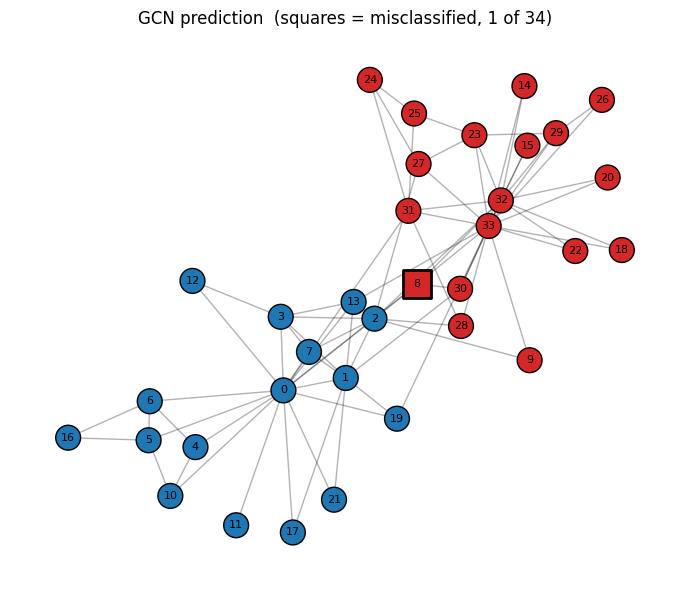

In [17]:
# Final prediction drawn on the graph. Squares = misclassified vs. the true split.
with torch.no_grad():
    pred = model(X_id, A_hat_t).argmax(1).cpu().numpy()
correct = pred == y_np

fig, ax = plt.subplots(figsize=(7, 6))
pos = nx.spring_layout(G, seed=2)
colors = ["#1f77b4" if p == 0 else "#d62728" for p in pred]
shapes_ok = [n for n in range(N) if correct[n]]
shapes_bad = [n for n in range(N) if not correct[n]]
nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=shapes_ok, node_color=[colors[n] for n in shapes_ok],
                       node_shape="o", node_size=320, edgecolors="k", ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=shapes_bad, node_color=[colors[n] for n in shapes_bad],
                       node_shape="s", node_size=380, edgecolors="k", linewidths=2.0, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
ax.set_title(f"GCN prediction  (squares = misclassified, {(~correct).sum()} of {N})")
ax.axis("off"); plt.tight_layout(); plt.show()

## Part 7 — GraphSAGE: sample and aggregate

GCN's rule bakes the *whole* normalized adjacency into the layer, which makes it **transductive** (it
needs the full graph at train time). **GraphSAGE** (Hamilton, Ying & Leskovec, 2017) is **inductive**: it
learns aggregator *functions* that generalize to unseen nodes/graphs. One layer is

$$ h_i' = \sigma\!\Big(W\cdot\big[\,h_i \,\Vert\, \mathrm{AGG}_{j\in\mathcal N(i)} h_j\,\big]\Big), $$

with $\mathrm{AGG}\in\{\text{mean},\text{pool},\text{LSTM}\}$ and (optionally) $\ell_2$-normalization of
$h_i'$. The **self** term $h_i$ is kept *separate* from the neighbor aggregate (unlike GCN, which mixes
them via self-loops) — this lets the model weigh "me" against "my neighborhood" differently.

A key identity: a linear map on a concatenation **is** two linear maps summed,
$W[a\Vert b]=W_{\text{self}}\,a + W_{\text{neigh}}\,b$, so we implement it with two `nn.Linear`s and a
**scatter-mean** aggregator (no self-loops needed — the self term is explicit).

In [18]:
def scatter_mean(messages, index, num_nodes):
    """Mean of `messages` grouped by destination `index`, returning [num_nodes, F]."""
    F_ = messages.size(1)
    out = torch.zeros(num_nodes, F_, device=messages.device)
    out.index_add_(0, index, messages)                   # sum messages per destination
    cnt = torch.zeros(num_nodes, device=messages.device)
    cnt.index_add_(0, index, torch.ones(index.size(0), device=messages.device))
    return out / cnt.clamp(min=1).unsqueeze(1)           # divide by neighbor count


class SAGELayer(nn.Module):
    """GraphSAGE (mean aggregator):  h' = W_self h + W_neigh * mean_{j in N(i)} h_j."""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin_self  = nn.Linear(in_dim, out_dim)
        self.lin_neigh = nn.Linear(in_dim, out_dim)
        for lin in (self.lin_self, self.lin_neigh):
            nn.init.xavier_uniform_(lin.weight); nn.init.zeros_(lin.bias)

    def forward(self, H, edge_index):
        src, dst = edge_index
        neigh = scatter_mean(H[src], dst, H.size(0))      # aggregate neighbors (no self-loop)
        return self.lin_self(H) + self.lin_neigh(neigh)


class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hid_dim, out_dim, dropout=0.1, l2_normalize=True):
        super().__init__()
        self.sage1 = SAGELayer(in_dim, hid_dim)
        self.sage2 = SAGELayer(hid_dim, out_dim)
        self.dropout = dropout; self.l2 = l2_normalize

    def forward(self, X, edge_index):
        h = F.relu(self.sage1(X, edge_index))
        if self.l2:
            h = F.normalize(h, p=2, dim=1)                # GraphSAGE-style row normalization
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.sage2(h, edge_index)

In [19]:
# Train GraphSAGE on the same Karate task (same 2 labels) for a head-to-head with GCN.
edge_index_t = torch.tensor(np.vstack(np.nonzero(A_k)), dtype=torch.long, device=DEVICE)

set_seed(1)
sage = GraphSAGE(in_dim=N, hid_dim=16, out_dim=2, dropout=0.1).to(DEVICE)
opt = torch.optim.Adam(sage.parameters(), lr=0.02, weight_decay=5e-4)

for epoch in range(0, 301):
    sage.train(); opt.zero_grad()
    logits = sage(X_id, edge_index_t)
    loss = F.cross_entropy(logits[train_mask], y_true[train_mask])
    loss.backward(); opt.step()

sage.eval()
with torch.no_grad():
    sage_acc = (sage(X_id, edge_index_t).argmax(1) == y_true).float().mean().item()
print(f"GraphSAGE final accuracy: {sage_acc:.3f}")
print(f"GCN       final accuracy: {history['acc'][-1]:.3f}")
print("\nBoth recover the split from 2 labels; SAGE keeps self vs. neighbor terms separate and")
print("is inductive (the learned aggregators transfer to nodes/graphs unseen at training time).")

GraphSAGE final accuracy: 0.824
GCN       final accuracy: 0.971

Both recover the split from 2 labels; SAGE keeps self vs. neighbor terms separate and
is inductive (the learned aggregators transfer to nodes/graphs unseen at training time).


## Part 8 — Graph Attention Networks (GAT)

GCN weights every neighbor by a *fixed* coefficient $1/\sqrt{\tilde d_i\tilde d_j}$ derived from degrees.
**GAT** (Veličković et al., 2018) instead *learns* how much each neighbor matters via attention.
For each edge $j\to i$:

$$ e_{ij} = \mathrm{LeakyReLU}\!\big(\mathbf a^\top[\,W h_i \,\Vert\, W h_j\,]\big),\qquad
   \alpha_{ij} = \mathrm{softmax}_{j\in\mathcal N(i)\cup\{i\}}(e_{ij}), $$

$$ h_i' = \sigma\!\Big(\textstyle\sum_{j} \alpha_{ij}\, W h_j\Big). $$

The softmax is **per destination node** (a "segment softmax" over each node's incoming edges).
**Multi-head** attention runs $K$ independent heads and concatenates (hidden layers) or averages (output
layer) them for stability. We decompose the additive score as
$\mathbf a^\top[Wh_i\Vert Wh_j]=\mathbf a_{\text{dst}}^\top Wh_i+\mathbf a_{\text{src}}^\top Wh_j$, which
makes the per-edge computation a couple of dot products.

In [20]:
def segment_softmax(scores, index, num_nodes):
    """Softmax of edge `scores` within each destination segment `index`.
    Subtracting the global max is a valid, segment-safe numerical stabilizer."""
    scores = scores - scores.max()
    exp = scores.exp()
    denom = torch.zeros(num_nodes, device=scores.device).index_add_(0, index, exp)
    return exp / (denom[index] + 1e-16)


class GATHead(nn.Module):
    """A single graph-attention head over edges (with self-loops added by the caller)."""
    def __init__(self, in_dim, out_dim, leaky=0.2):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.a_src = nn.Parameter(torch.empty(out_dim))   # attends to neighbor (source)
        self.a_dst = nn.Parameter(torch.empty(out_dim))   # attends to center (destination)
        nn.init.xavier_uniform_(self.W.weight)
        nn.init.normal_(self.a_src, std=0.1); nn.init.normal_(self.a_dst, std=0.1)
        self.leaky = nn.LeakyReLU(leaky)

    def forward(self, H, edge_index, num_nodes):
        Wh = self.W(H)                                    # [N, out]
        src, dst = edge_index                             # message flows src(j) -> dst(i)
        e = self.leaky((Wh[dst] * self.a_dst).sum(-1) + (Wh[src] * self.a_src).sum(-1))  # [E]
        alpha = segment_softmax(e, dst, num_nodes)        # normalize over each node's neighbors
        out = torch.zeros(num_nodes, Wh.size(1), device=H.device)
        out.index_add_(0, dst, alpha.unsqueeze(-1) * Wh[src])   # weighted sum of neighbor features
        return out, alpha


class MultiHeadGAT(nn.Module):
    """K attention heads, concatenated (concat=True) or averaged (concat=False)."""
    def __init__(self, in_dim, out_dim, heads=4, concat=True, leaky=0.2):
        super().__init__()
        self.heads = nn.ModuleList([GATHead(in_dim, out_dim, leaky) for _ in range(heads)])
        self.concat = concat

    def forward(self, H, edge_index, num_nodes):
        outs, alphas = zip(*[h(H, edge_index, num_nodes) for h in self.heads])
        H_out = torch.cat(outs, dim=1) if self.concat else torch.stack(outs).mean(0)
        return H_out, alphas


class GAT(nn.Module):
    """2-layer GAT: K concatenated heads, then a single averaging head to the classes."""
    def __init__(self, in_dim, hid_dim, out_dim, heads=4, dropout=0.2):
        super().__init__()
        self.gat1 = MultiHeadGAT(in_dim, hid_dim, heads=heads, concat=True)
        self.gat2 = MultiHeadGAT(hid_dim * heads, out_dim, heads=1, concat=False)
        self.dropout = dropout

    def forward(self, X, edge_index, num_nodes):
        h, _ = self.gat1(X, edge_index, num_nodes)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        logits, self.last_alpha = self.gat2(h, edge_index, num_nodes)
        return logits

In [21]:
# GAT needs self-loops in the edge list so each node can attend to itself.
edge_index_sl = torch.tensor(add_self_loops(np.vstack(np.nonzero(A_k)), N),
                             dtype=torch.long, device=DEVICE)

set_seed(1)
gat = GAT(in_dim=N, hid_dim=8, out_dim=2, heads=4, dropout=0.2).to(DEVICE)
opt = torch.optim.Adam(gat.parameters(), lr=0.02, weight_decay=5e-4)

for epoch in range(0, 301):
    gat.train(); opt.zero_grad()
    logits = gat(X_id, edge_index_sl, N)
    loss = F.cross_entropy(logits[train_mask], y_true[train_mask])
    loss.backward(); opt.step()

gat.eval()
with torch.no_grad():
    gat_acc = (gat(X_id, edge_index_sl, N).argmax(1) == y_true).float().mean().item()
print(f"GAT final accuracy: {gat_acc:.3f}   (heads=4)")
print("GAT learns *which* neighbors matter instead of fixing weights by degree.")

GAT final accuracy: 0.882   (heads=4)
GAT learns *which* neighbors matter instead of fixing weights by degree.


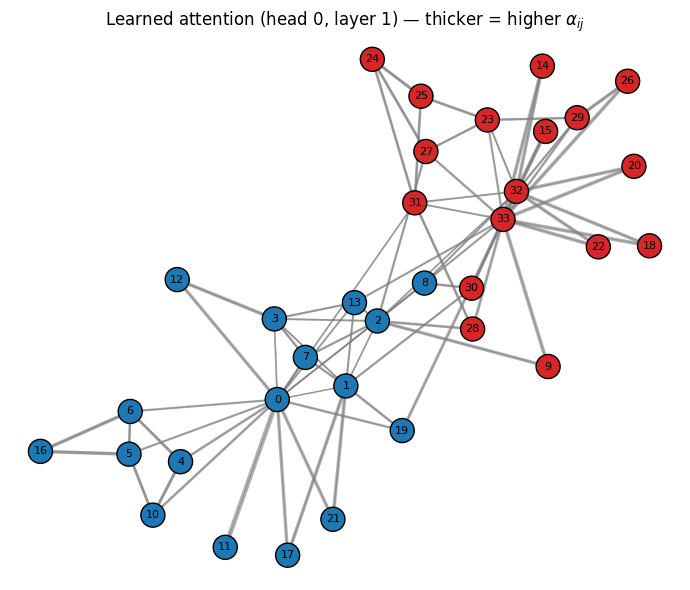

In [22]:
# Visualize learned attention from one head of layer 1: edge width ~ attention weight.
gat.eval()
with torch.no_grad():
    _, alphas = gat.gat1(X_id, edge_index_sl, N)
alpha0 = alphas[0].cpu().numpy()                          # head 0 weights, one per directed edge
ei_sl = edge_index_sl.cpu().numpy()

fig, ax = plt.subplots(figsize=(7, 6))
pos = nx.spring_layout(G, seed=2)
nx.draw_networkx_nodes(G, pos, node_color=[("#1f77b4" if p == 0 else "#d62728") for p in y_np],
                       node_size=300, edgecolors="k", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
# draw non-self edges with width proportional to attention
for k in range(ei_sl.shape[1]):
    j, i = ei_sl[0, k], ei_sl[1, k]
    if j == i:
        continue
    ax.plot([pos[j][0], pos[i][0]], [pos[j][1], pos[i][1]],
            color="gray", alpha=0.6, linewidth=0.5 + 6.0 * alpha0[k], zorder=0)
ax.set_title("Learned attention (head 0, layer 1) — thicker = higher $\\alpha_{ij}$")
ax.axis("off"); plt.tight_layout(); plt.show()

## Part 9 — Graph-level tasks: readout and batching

For **graph classification** we need one vector per *graph*, not per node. A permutation-invariant
**readout** pools the node embeddings:

$$ h_G = \mathrm{READOUT}\big(\{h_i : i\in V\}\big) \in \{\text{mean},\,\text{sum},\,\text{max}\}. $$

**Batching many graphs.** GNN libraries batch a set of graphs into one big **disconnected** graph: stack
the adjacency matrices **block-diagonally** and keep a `batch` vector telling which graph each node
belongs to. A single forward pass processes the whole batch, and a *segmented* mean over `batch` does the
per-graph readout. We demonstrate on a synthetic task: **sparse vs. dense** Erdős–Rényi graphs, where
each node is described by its **degree** (a purely structural feature). Message passing mixes
neighborhoods and a mean-pool readout summarizes each graph into one vector for the classifier.

In [23]:
def make_graph_dataset(n_per_class=60, seed=0):
    """Two classes of Erdos-Renyi graphs: 0 = sparse (p~0.15), 1 = dense (p~0.45)."""
    rng = np.random.default_rng(seed)
    data = []
    for label, p in [(0, 0.15), (1, 0.45)]:
        for _ in range(n_per_class):
            n = int(rng.integers(12, 21))
            G = nx.erdos_renyi_graph(n, p, seed=int(rng.integers(1e9)))
            # guarantee no isolated nodes so degrees are well defined
            for v in list(nx.isolates(G)):
                G.add_edge(v, int(rng.integers(0, n)))
            data.append((nx.to_numpy_array(G, nodelist=range(n)), label))
    rng.shuffle(data)
    return data

def collate(graphs):
    """Block-diagonal batching: big A_hat, constant features X, and a `batch` index vector."""
    from scipy.linalg import block_diag
    A_hats, feats, batch, ys = [], [], [], []
    for gi, (A, y) in enumerate(graphs):
        A_hats.append(gcn_norm(A))
        deg = A.sum(1, keepdims=True)                     # node degree = structural feature
        feats.append(np.concatenate([np.ones_like(deg), deg], axis=1))   # [bias, degree]
        batch += [gi] * A.shape[0]
        ys.append(y)
    A_big = block_diag(*A_hats)                            # disconnected union of all graphs
    return (torch.tensor(A_big, dtype=torch.float32, device=DEVICE),
            torch.tensor(np.vstack(feats), dtype=torch.float32, device=DEVICE),
            torch.tensor(batch, dtype=torch.long, device=DEVICE),
            torch.tensor(ys, dtype=torch.long, device=DEVICE))

data = make_graph_dataset()
split = int(0.7 * len(data))
train_batch = collate(data[:split])
test_batch  = collate(data[split:])
print(f"{len(data)} graphs  ->  {split} train / {len(data)-split} test")
print("train batch: A_hat", tuple(train_batch[0].shape), "| nodes", train_batch[1].shape[0],
      "| graphs", int(train_batch[2].max())+1)

120 graphs  ->  84 train / 36 test
train batch: A_hat (1354, 1354) | nodes 1354 | graphs 84


In [24]:
def global_mean_pool(H, batch, num_graphs):
    """Per-graph mean of node embeddings (segmented mean over the batch vector)."""
    out = torch.zeros(num_graphs, H.size(1), device=H.device).index_add_(0, batch, H)
    cnt = torch.zeros(num_graphs, device=H.device).index_add_(
        0, batch, torch.ones(batch.size(0), device=H.device))
    return out / cnt.clamp(min=1).unsqueeze(1)


class GraphClassifier(nn.Module):
    """GCN encoder -> global mean pool -> MLP head -> graph logits."""
    def __init__(self, in_dim, hid_dim, num_classes, dropout=0.2):
        super().__init__()
        self.gc1 = GCNLayer(in_dim, hid_dim)
        self.gc2 = GCNLayer(hid_dim, hid_dim)
        self.head = nn.Linear(hid_dim, num_classes)
        self.dropout = dropout

    def forward(self, X, A_hat, batch, num_graphs):
        h = F.relu(self.gc1(X, A_hat))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.gc2(h, A_hat))
        hG = global_mean_pool(h, batch, num_graphs)        # node -> graph
        return self.head(hG)

In [25]:
set_seed(0)
clf = GraphClassifier(in_dim=2, hid_dim=32, num_classes=2, dropout=0.2).to(DEVICE)
opt = torch.optim.Adam(clf.parameters(), lr=0.01, weight_decay=5e-4)

A_tr, X_tr, b_tr, y_tr = train_batch
A_te, X_te, b_te, y_te = test_batch
ng_tr, ng_te = int(b_tr.max())+1, int(b_te.max())+1

for epoch in range(0, 121):
    clf.train(); opt.zero_grad()
    out = clf(X_tr, A_tr, b_tr, ng_tr)
    loss = F.cross_entropy(out, y_tr)
    loss.backward(); opt.step()
    if epoch % 30 == 0:
        clf.eval()
        with torch.no_grad():
            tr_acc = (clf(X_tr, A_tr, b_tr, ng_tr).argmax(1) == y_tr).float().mean().item()
            te_acc = (clf(X_te, A_te, b_te, ng_te).argmax(1) == y_te).float().mean().item()
        print(f"epoch {epoch:3d} | loss {loss.item():.4f} | train acc {tr_acc:.3f} | test acc {te_acc:.3f}")

clf.eval()
with torch.no_grad():
    te_acc = (clf(X_te, A_te, b_te, ng_te).argmax(1) == y_te).float().mean().item()
print(f"\nGraph-classification test accuracy: {te_acc:.3f}")
print("Each node carries its degree; message passing mixes neighborhoods and the mean-pool")
print("readout turns them into a graph-level density estimate the linear head separates cleanly.")

epoch   0 | loss 0.6632 | train acc 0.452 | test acc 0.611
epoch  30 | loss 0.0575 | train acc 0.952 | test acc 0.972
epoch  60 | loss 0.0627 | train acc 0.952 | test acc 0.972
epoch  90 | loss 0.0580 | train acc 0.964 | test acc 0.972
epoch 120 | loss 0.0590 | train acc 0.952 | test acc 0.972

Graph-classification test accuracy: 0.972
Each node carries its degree; message passing mixes neighborhoods and the mean-pool
readout turns them into a graph-level density estimate the linear head separates cleanly.


## Part 10 — Limitations and theory

GNNs have three well-understood failure modes you should know before deploying them.

### 10a. Over-smoothing
Each layer is a low-pass filter. Stacking many of them drives every node's representation toward the
same value — the Dirichlet energy of the embeddings decays toward zero and nodes become
**indistinguishable**. This caps the useful depth of vanilla GCNs at ~2–4 layers. We demonstrate the
exponential energy decay and the rise of pairwise similarity under repeated propagation $\hat A^k X$.

### 10b. Over-squashing
A node's receptive field grows exponentially with depth ($\sim$ degree$^k$ nodes at $k$ hops), but all
that information is crushed into one fixed-size vector. Long-range signals get "squashed" through graph
bottlenecks, so tasks needing distant interactions suffer. Remedies: rewiring, virtual/global nodes,
attention, Transformers-on-graphs.

### 10c. Expressive power (the 1-WL ceiling)
Message-passing GNNs are **at most as powerful as the 1-dimensional Weisfeiler–Leman** graph isomorphism
test (Xu et al., 2019). If 1-WL can't tell two graphs apart, neither can *any* MPNN with the same input
features. **GIN** reaches this bound with sum aggregation + an MLP; mean/max are strictly weaker. Below we
show a classic 1-WL-blind pair — a 6-cycle vs. two triangles — that produces **identical** readouts.

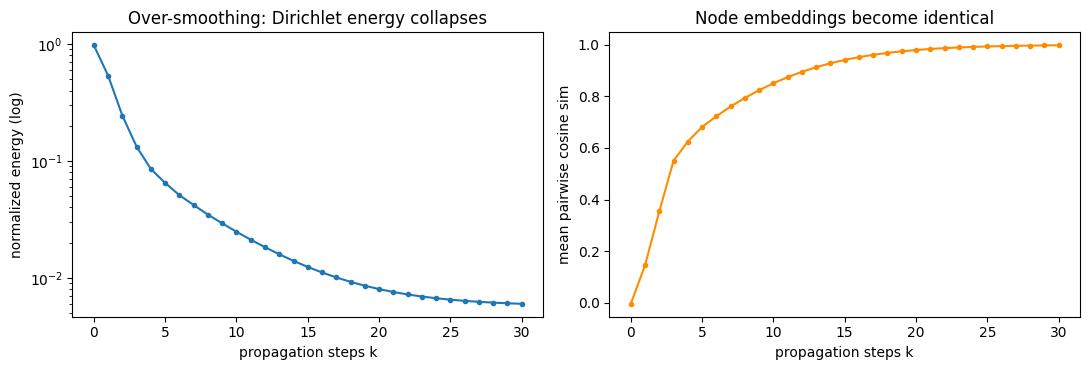

energy(k=0) = 0.9763  ->  energy(k=30) = 5.99e-03
mean cosine sim  -0.003 (k=0)  ->  0.998 (k=30): everything has merged.


In [26]:
# 10a. Over-smoothing: repeated propagation A_hat^k X collapses the signal.
set_seed(0)
Xos = np.random.default_rng(0).normal(size=(A_k.shape[0], 8))   # random 8-D node signals
_, L_sym_k = laplacians(A_k)

H = Xos.copy()
energies, sims, ks = [], [], list(range(0, 31))
for k in ks:
    # normalized Dirichlet energy: smoothness relative to signal magnitude
    e = dirichlet_energy(H, L_sym_k) / (np.linalg.norm(H) ** 2 + 1e-12)
    energies.append(e)
    Hn = H / (np.linalg.norm(H, axis=1, keepdims=True) + 1e-12)
    C = Hn @ Hn.T
    iu = np.triu_indices(len(C), k=1)
    sims.append(float(C[iu].mean()))                           # mean pairwise cosine similarity
    H = A_hat @ H                                              # one more propagation step

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(ks, energies, marker="o", ms=3); ax[0].set_yscale("log")
ax[0].set_title("Over-smoothing: Dirichlet energy collapses")
ax[0].set_xlabel("propagation steps k"); ax[0].set_ylabel("normalized energy (log)")
ax[1].plot(ks, sims, marker="o", ms=3, color="darkorange")
ax[1].set_title("Node embeddings become identical")
ax[1].set_xlabel("propagation steps k"); ax[1].set_ylabel("mean pairwise cosine sim")
plt.tight_layout(); plt.show()
print(f"energy(k=0) = {energies[0]:.4f}  ->  energy(k=30) = {energies[-1]:.2e}")
print(f"mean cosine sim  {sims[0]:.3f} (k=0)  ->  {sims[-1]:.3f} (k=30): everything has merged.")

In [27]:
# 10c. The 1-WL ceiling: a 6-cycle and two disjoint triangles are both 2-regular.
# With constant features, ANY message-passing GNN gives them identical graph readouts.
C6  = nx.cycle_graph(6)                                    # one 6-cycle
TT  = nx.disjoint_union(nx.cycle_graph(3), nx.cycle_graph(3))  # two triangles

def readout_constant_feature(graph, steps=3):
    """Run a few GCN propagation steps from a constant feature, then mean-pool."""
    A = nx.to_numpy_array(graph, nodelist=range(graph.number_of_nodes()))
    Ah = gcn_norm(A)
    H = np.ones((graph.number_of_nodes(), 1))             # identical constant feature
    for _ in range(steps):
        H = Ah @ H
    return H.mean(0)                                      # graph-level readout

r_c6, r_tt = readout_constant_feature(C6), readout_constant_feature(TT)
print("Both graphs are 2-regular:",
      sorted(d for _, d in C6.degree()) == sorted(d for _, d in TT.degree()) == [2]*6)
print(f"readout(6-cycle)      = {r_c6}")
print(f"readout(two triangles)= {r_tt}")
print("Identical readouts -> indistinguishable:", np.allclose(r_c6, r_tt))

# Remedy: give nodes distinguishing features (random / positional encodings) and the tie breaks.
rng = np.random.default_rng(0)
def readout_random_feature(graph, steps=3):
    A = nx.to_numpy_array(graph, nodelist=range(graph.number_of_nodes()))
    Ah = gcn_norm(A)
    H = rng.normal(size=(graph.number_of_nodes(), 4))
    for _ in range(steps):
        H = Ah @ H
    return H.mean(0)
print("\nWith random node features, readouts now differ:",
      not np.allclose(readout_random_feature(C6), readout_random_feature(TT), atol=1e-3))
print("Lesson: structure-only MPNNs hit the 1-WL wall; positional/structural features push past it.")

Both graphs are 2-regular: True
readout(6-cycle)      = [1.]
readout(two triangles)= [1.]
Identical readouts -> indistinguishable: True

With random node features, readouts now differ: True
Lesson: structure-only MPNNs hit the 1-WL wall; positional/structural features push past it.


## Part 11 — Cheat sheet and references

### Layer update rules at a glance

| Layer | Per-node update | Neighbor weighting | Key trait |
|---|---|---|---|
| **GCN** | $h_i'=\sigma\big(\sum_{j\in\mathcal N(i)\cup\{i\}}\tfrac{1}{\sqrt{\tilde d_i\tilde d_j}}\,h_j W\big)$ | fixed (degree) | simple, transductive |
| **GraphSAGE** | $h_i'=\sigma\big(W[h_i\,\Vert\,\mathrm{AGG}_j h_j]\big)$ | uniform within AGG | inductive, samples neighbors |
| **GAT** | $h_i'=\sigma\big(\sum_j \alpha_{ij}\,h_j W\big)$ | **learned** ($\alpha_{ij}$) | attention, multi-head |
| **GIN** | $h_i'=\mathrm{MLP}\big((1+\epsilon)h_i+\sum_j h_j\big)$ | sum | maximally expressive (1-WL) |
| **MPNN** (general) | $h_i'=\mathrm{UPDATE}(h_i,\,\bigoplus_j \mathrm{MSG}(h_i,h_j,e_{ij}))$ | any | the umbrella framework |

### Design checklist
- **Task?** node / edge / graph → choose the right head and (for graph-level) a permutation-invariant readout.
- **Transductive vs inductive?** Full fixed graph → GCN is fine. Unseen nodes/graphs → GraphSAGE / GAT / GIN.
- **Depth?** Start at 2–3 layers. Going deeper → add residual/jumping-knowledge connections, `PairNorm`,
  or `DropEdge` to fight **over-smoothing**.
- **Long-range dependencies?** Beware **over-squashing**; consider graph rewiring, virtual nodes, or graph Transformers.
- **Need to distinguish subtle structures?** Recall the **1-WL ceiling**; add positional/structural
  encodings or use higher-order/subgraph GNNs.

### To go further with libraries
The from-scratch layers here map 1:1 onto **PyTorch Geometric** (`GCNConv`, `SAGEConv`, `GATConv`,
`GINConv`, `global_mean_pool`) and **DGL**. Neither is installed in `MLENV311`; to add PyG, match the
wheel to this exact Torch build, e.g. `pip install torch_geometric` (pure-Python core) and the optional
`pyg-lib`/`torch-scatter` wheels built for your `torch.__version__`.

### Canonical references
- Kipf & Welling (2017), *Semi-Supervised Classification with GCNs* — [arXiv:1609.02907](https://arxiv.org/abs/1609.02907)
- Hamilton, Ying & Leskovec (2017), *Inductive Representation Learning (GraphSAGE)* — [arXiv:1706.02216](https://arxiv.org/abs/1706.02216)
- Veličković et al. (2018), *Graph Attention Networks* — [arXiv:1710.10903](https://arxiv.org/abs/1710.10903)
- Gilmer et al. (2017), *Neural Message Passing for Quantum Chemistry (MPNN)* — [arXiv:1704.01212](https://arxiv.org/abs/1704.01212)
- Xu et al. (2019), *How Powerful are Graph Neural Networks? (GIN)* — [arXiv:1810.00826](https://arxiv.org/abs/1810.00826)
- Defferrard, Bresson & Vandergheynst (2016), *ChebNet* — [arXiv:1606.09375](https://arxiv.org/abs/1606.09375)
- Bruna et al. (2014), *Spectral Networks* — [arXiv:1312.6203](https://arxiv.org/abs/1312.6203)
- Li, Han & Wu (2018), *Deeper Insights into GCNs (over-smoothing)* — [arXiv:1801.07606](https://arxiv.org/abs/1801.07606)
- Alon & Yahav (2021), *On the Bottleneck of GNNs (over-squashing)* — [arXiv:2006.05205](https://arxiv.org/abs/2006.05205)
- Bronstein, Bruna, Cohen & Veličković (2021), *Geometric Deep Learning* — [arXiv:2104.13478](https://arxiv.org/abs/2104.13478)
- Hamilton (2020), *Graph Representation Learning* (book) — [free PDF](https://www.cs.mcgill.ca/~wlh/grl_book/)

---
*Built from scratch on `MLENV311` (PyTorch 2.12). Every layer above is ~10–40 lines — the math is the model.*